# IMPORTING the dataset

In [28]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, classification_report

In [29]:

df=pd.read_csv(r"C:\Users\ABHAY SINGH\OneDrive\Documents\Desktop\AI TWIN\ultimate_student_productivity_dataset_5000.csv")
df

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63


In [30]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

# Checking the null values

In [31]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [32]:
if "student_id" in df.columns:
    df.drop("student_id", axis=1, inplace=True)

In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   object 
 2   academic_level        5000 non-null   object 
 3   study_hours           5000 non-null   float64
 4   self_study_hours      5000 non-null   float64
 5   online_classes_hours  5000 non-null   float64
 6   social_media_hours    5000 non-null   float64
 7   gaming_hours          5000 non-null   float64
 8   sleep_hours           5000 non-null   float64
 9   screen_time_hours     5000 non-null   float64
 10  exercise_minutes      5000 non-null   int64  
 11  caffeine_intake_mg    5000 non-null   int64  
 12  part_time_job         5000 non-null   int64  
 13  upcoming_deadline     5000 non-null   int64  
 14  internet_quality      5000 non-null   object 
 15  mental_health_score  

In [34]:
df = pd.get_dummies(df, drop_first=True)

In [35]:
y_productivity= df["productivity_score"]
y_burnout= df["burnout_level"]

In [36]:
y_burnout_cat=pd.cut(y_burnout,bins=[0,40,70,100],labels=["low","Medium","Hard"],include_lowest=True)

In [37]:
X=df.drop([
    "productivity_score",
    "burnout_level",
    "exam_score",
    "focus_index"
], axis=1)

joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [38]:
X_train, X_test, y_prod_train,y_prod_test,y_burn_train,y_burn_test=train_test_split(
    X,y_productivity,y_burnout_cat,
    test_size=0.2,
    random_state=42
    )

In [39]:


scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
reg_model=RandomForestRegressor(n_estimators=200,random_state=42)
reg_model.fit(X_train_scaled, y_prod_train)

y_pred_prod=reg_model.predict(X_test_scaled)

print("prod model result")
print("R2 score:" , r2_score(y_prod_test,y_pred_prod))
print("MAE: ", mean_absolute_error(y_prod_test,y_pred_prod))

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_prod_test, y_pred_prod))
print("RMSE:", round(rmse, 3))

joblib.dump(reg_model,"productivity_model.pkl")


prod model result
R2 score: 0.8418644074891353
MAE:  5.134095749999999
RMSE: 6.417


['productivity_model.pkl']

In [41]:
train_score = reg_model.score(X_train_scaled, y_prod_train)
test_score = reg_model.score(X_test_scaled, y_prod_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.980328351368152
Test R2: 0.8418644074891353


In [42]:
clf_model=RandomForestClassifier(n_estimators=200, random_state=42)
clf_model.fit(X_train_scaled,y_burn_train)

y_pred_burn=clf_model.predict(X_test_scaled)

print("burn model result")
print("Accuracy: ", accuracy_score(y_burn_test,y_pred_burn))
print(classification_report(y_burn_test,y_pred_burn))

joblib.dump(clf_model,"burnout_model.pkl")



burn model result
Accuracy:  0.84
              precision    recall  f1-score   support

        Hard       0.75      0.15      0.24        41
      Medium       0.84      0.91      0.87       607
         low       0.85      0.80      0.82       352

    accuracy                           0.84      1000
   macro avg       0.81      0.62      0.65      1000
weighted avg       0.84      0.84      0.83      1000



['burnout_model.pkl']

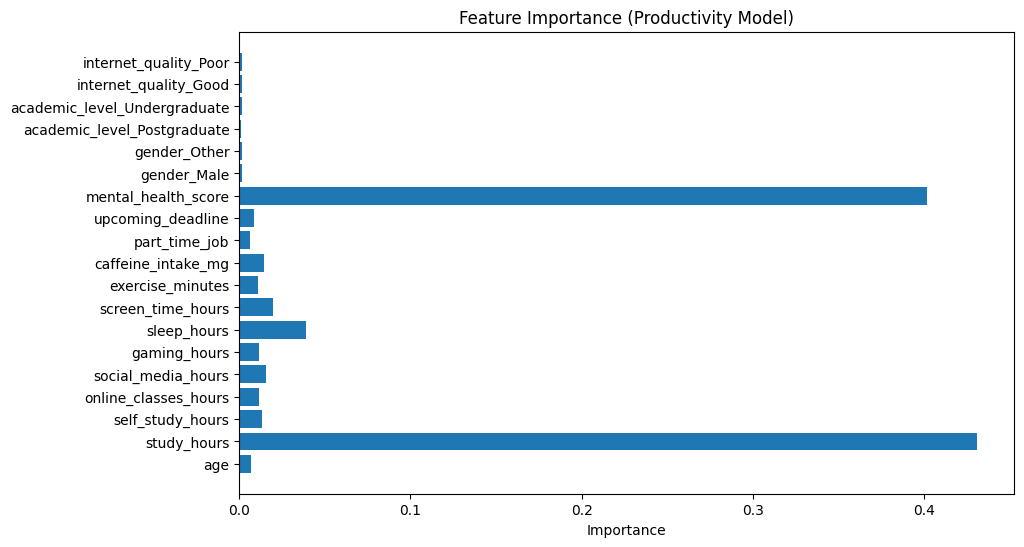

In [43]:
import matplotlib.pyplot as plt
importance = reg_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance (Productivity Model)")
plt.xlabel("Importance")
plt.show()

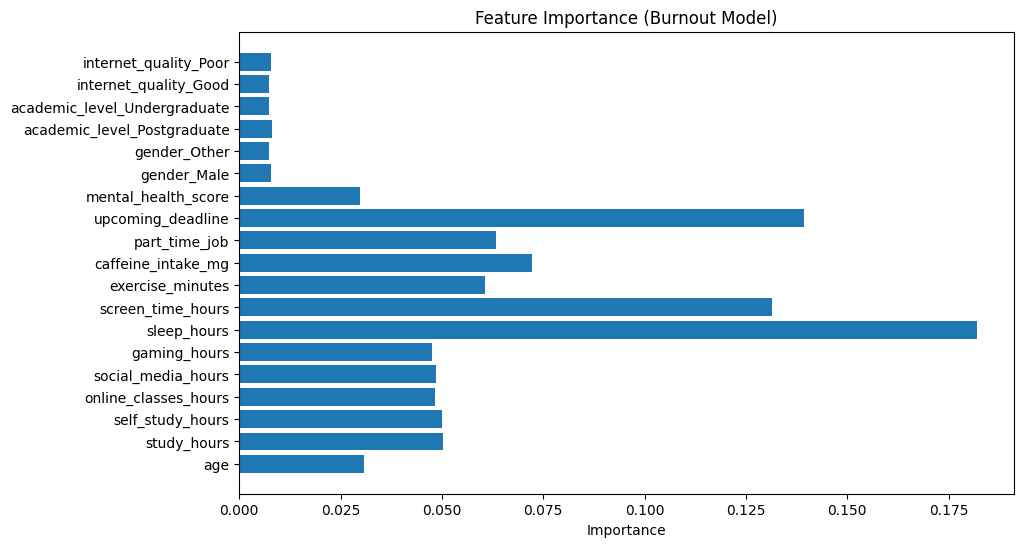

In [44]:
importance = clf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance (Burnout Model)")
plt.xlabel("Importance")
plt.show()